In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. SIGMOID FUNCTION
- **Formula:** σ(x) = 1 / (1 + e^(-x))
- **Range:** (0, 1)
- **Use:** Binary classification (output layer), historically popular for hidden layers

In [2]:
def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    """Derivative of sigmoid"""
    s = sigmoid(x)
    return s * (1 - s)

## 2. TANH (Hyperbolic Tangent) FUNCTION
- **Formula:** tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
- **Range:** (-1, 1)
- **Use:** Hidden layers, better than sigmoid (zero-centered output)

In [3]:
def tanh(x):
    """Tanh activation function"""
    return np.tanh(x)

def tanh_derivative(x):
    """Derivative of tanh"""
    return 1 - np.tanh(x)**2

## 3. ReLU (Rectified Linear Unit) FUNCTION
- **Formula:** ReLU(x) = max(0, x)
- **Range:** [0, ∞)
- **Use:** Most popular in deep learning, hidden layers, faster training

In [4]:
def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU"""
    return (x > 0).astype(float)

## 4. LEAKY ReLU FUNCTION
- **Formula:** LeakyReLU(x) = x if x > 0, else α*x (α=0.01)
- **Range:** (-∞, ∞)
- **Use:** Improves ReLU by preventing dying ReLU problem

In [5]:
def leaky_relu(x, alpha=0.01):
    """Leaky ReLU activation function"""
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    """Derivative of Leaky ReLU"""
    return np.where(x > 0, 1, alpha)

## 5. ELU (Exponential Linear Unit) FUNCTION
- **Formula:** ELU(x) = x if x > 0, else α*(e^x - 1)
- **Range:** (-α, ∞)
- **Use:** Better convergence, smoother than Leaky ReLU

In [6]:
def elu(x, alpha=1.0):
    """ELU activation function"""
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
    """Derivative of ELU"""
    return np.where(x > 0, 1, alpha * np.exp(x))

## 6. SELU (Scaled Exponential Linear Unit) FUNCTION
- **Formula:** SELU(x) = λ * ELU(x), where λ ≈ 1.0507, α ≈ 1.6733
- **Range:** (-λ*α, ∞)
- **Use:** Self-normalizing networks, improves gradient flow

In [7]:
def selu(x):
    """SELU activation function"""
    lambda_val = 1.0507
    alpha = 1.6733
    return lambda_val * np.where(x > 0, x, alpha * (np.exp(x) - 1))

def selu_derivative(x):
    """Derivative of SELU"""
    lambda_val = 1.0507
    alpha = 1.6733
    return lambda_val * np.where(x > 0, 1, alpha * np.exp(x))

## 7. SOFTMAX FUNCTION
- **Formula:** Softmax(x_i) = e^(x_i) / Σ(e^(x_j))
- **Range:** (0, 1), sum = 1
- **Use:** Multi-class classification (output layer), probability distribution

In [8]:
def softmax(x):
    """Softmax activation function"""
    # For numerical stability
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

def softmax_derivative(x):
    """Derivative of Softmax"""
    s = softmax(x)
    return s * (1 - s)

## 8. SWISH (SiLU - Sigmoid Linear Unit) FUNCTION
- **Formula:** Swish(x) = x * sigmoid(β*x)
- **Range:** (-0.27, ∞) approximately
- **Use:** Modern networks, often outperforms ReLU

In [9]:
def swish(x, beta=1.0):
    """Swish activation function"""
    return x * sigmoid(beta * x)

def swish_derivative(x, beta=1.0):
    """Derivative of Swish"""
    s = sigmoid(beta * x)
    return s + beta * x * s * (1 - s)

## 9. GELU (Gaussian Error Linear Unit) FUNCTION
- **Formula:** GELU(x) = x * Φ(x), where Φ is Gaussian CDF
- **Range:** (-0.17, ∞) approximately
- **Use:** Transformer models (BERT, GPT), state-of-the-art

In [10]:
def gelu(x):
    """GELU activation function (approximation)"""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def gelu_derivative(x):
    """Derivative of GELU (approximation)"""
    cdf = 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
    pdf = 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2)
    return cdf + x * pdf

## 10. MISH FUNCTION
- **Formula:** Mish(x) = x * tanh(softplus(x)) = x * tanh(ln(1 + e^x))
- **Range:** (-0.30, ∞) approximately
- **Use:** Self-regularizing, smooth activation for modern architectures

In [11]:
def mish(x):
    """Mish activation function"""
    return x * np.tanh(np.log(1 + np.exp(x)))

def mish_derivative(x):
    """Derivative of Mish"""
    sp = np.log(1 + np.exp(x))
    return np.tanh(sp) + x * (1 - np.tanh(sp)**2) * sigmoid(x)

## 11. LINEAR (IDENTITY) FUNCTION
- **Formula:** Linear(x) = x
- **Range:** (-∞, ∞)
- **Use:** Output layer for regression, hidden layers rarely

In [12]:
def linear(x):
    """Linear activation function"""
    return x

def linear_derivative(x):
    """Derivative of Linear"""
    return np.ones_like(x)

# VISUALIZATION: All Activation Functions

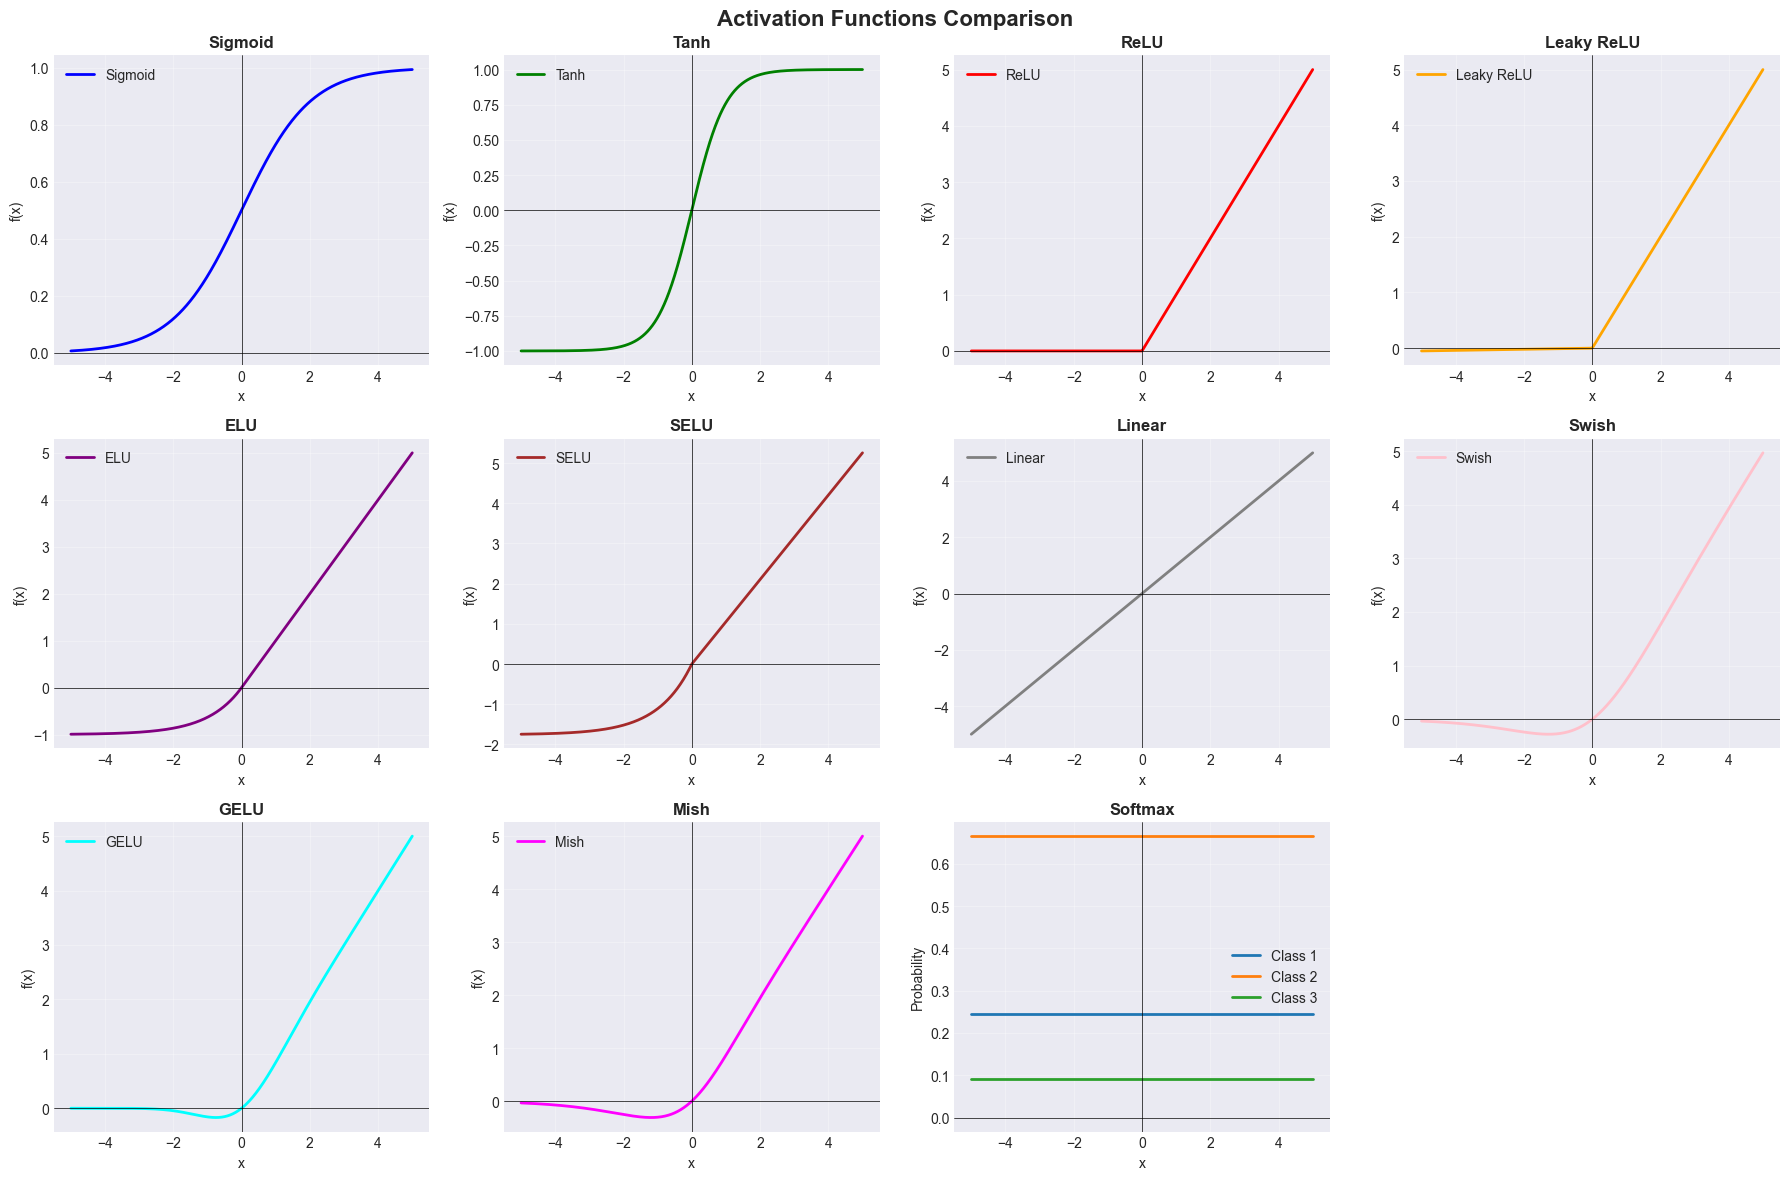

In [13]:
# Create input data
x = np.linspace(-5, 5, 1000)

# Create figure with subplots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Activation Functions Comparison', fontsize=16, fontweight='bold')

# Plot each activation function
activations = [
    ('Sigmoid', sigmoid, 'blue'),
    ('Tanh', tanh, 'green'),
    ('ReLU', relu, 'red'),
    ('Leaky ReLU', leaky_relu, 'orange'),
    ('ELU', elu, 'purple'),
    ('SELU', selu, 'brown'),
    ('Linear', linear, 'gray'),
    ('Swish', swish, 'pink'),
    ('GELU', gelu, 'cyan'),
    ('Mish', mish, 'magenta'),
]

axes = axes.flatten()

for idx, (name, func, color) in enumerate(activations):
    ax = axes[idx]
    y = func(x)
    ax.plot(x, y, color=color, linewidth=2, label=name)
    ax.grid(True, alpha=0.3)
    ax.set_title(name, fontweight='bold')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()

# Plot Softmax (separate as it's different)
ax = axes[10]
x_softmax = np.linspace(-5, 5, 100)
logits = np.array([x_softmax, x_softmax + 1, x_softmax - 1]).T
probs = softmax(logits)
ax.plot(x_softmax, probs[:, 0], label='Class 1', linewidth=2)
ax.plot(x_softmax, probs[:, 1], label='Class 2', linewidth=2)
ax.plot(x_softmax, probs[:, 2], label='Class 3', linewidth=2)
ax.grid(True, alpha=0.3)
ax.set_title('Softmax', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Probability')
ax.legend()
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

# Hide the last subplot
axes[11].axis('off')

plt.tight_layout()
plt.show()